In [1]:
from pathlib import Path
import gzip
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from stable_platform_matchings.domain.instance import Instance
import seaborn as sns
from pprint import pprint

In [2]:
sns.set_theme(context="paper", style="ticks")

In [3]:
root = Path("../results/exp_3")
all_jsons = list(root.rglob("*.json.gz"))
graph_data_filename = "../data/graph_0-14960_00_new.pickle"
instance = Instance.from_yaml(Path('../data/anon_14_day_instances/2020-08-27.yaml'))

In [4]:
LC_TO_USD = instance.lc_to_usd
TRUCK_FIXED_COST = instance.truck_fixed_cost

MAX_DEVIATION_POTENTIAL = 12

DEV_POT_BINS = np.linspace(2, 12, 7)
COST_BINS = np.linspace(65, 110, 7)

ZERO_TOL = 1e-8


def currency_formatter(x, pos):
    return f"${x:.0f}"


plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})


In [5]:
data = []

for file in all_jsons:
    with gzip.open(file, "rt", encoding="utf-8") as f:
        aggregate_payload = json.load(f)

    job_id = aggregate_payload["job_id"]

    for payload in aggregate_payload["n_hist_sets"]:
        n_hist_sets = payload["metadata"]["n_hist_sets"]
        time_suboptimal = payload["summary"]["timestamps"][0]
        total_time = payload["summary"]["total_time"]
        hist_set_method = payload["metadata"]["hist_set_method"]

        instance_snapshot = payload["summary"]["instance_snapshot"]
        instance_id = instance_snapshot["instance_id"]

        epsilons = payload["sampled_inputs"]["epsilons"]
        het_costs = payload["sampled_inputs"]["het_costs"]
        intermediaries = instance_snapshot["intermediaries"]

        avg_epsilon = np.mean(list(epsilons.values()))

        total_quantity = sum(
            farmer["quantity"] for farmer in instance_snapshot["farmers"]
        )

        total_fruit_value = total_quantity * instance.fruit_price_per_ton

        result = payload["summary"]["platform_solve_result"]

        primary_result = result["primary_result"]

        max_int_result = result["max_intermediary_welfare_result"]

        max_farmer_result = result["max_farmer_welfare_result"]

        platform_profit = max_int_result["platform_profit"]

        max_intermediary_welfare = max_int_result["intermediary_welfare"]
        min_intermediary_welfare = max_farmer_result["intermediary_welfare"]

        min_farmer_welfare = max_int_result["farmer_welfare"]
        max_farmer_welfare = max_farmer_result["farmer_welfare"]

        row = {
            "job_id": job_id,
            "hist_set_method": hist_set_method,
            "n_hist_sets": n_hist_sets,
            "total_time": total_time,
            "time_suboptimal": time_suboptimal,
            "avg_epsilon": avg_epsilon,
            "platform_profit_pct": platform_profit / total_fruit_value * 100,
            "min_intermediary_welfare_pct": min_intermediary_welfare / total_fruit_value * 100,
            "max_intermediary_welfare_pct": max_intermediary_welfare / total_fruit_value * 100,
            "min_farmer_welfare_pct": min_farmer_welfare / total_fruit_value * 100,
            "max_farmer_welfare_pct": max_farmer_welfare / total_fruit_value * 100
        }

        data.append(row)

df = pd.DataFrame(data)
df_original = df.query("hist_set_method == 'original'")

In [6]:
baseline = df_original.query("n_hist_sets == 1").set_index('job_id')[['platform_profit_pct', 'max_intermediary_welfare_pct', 'min_farmer_welfare_pct']]
df_original['platform_profit_pct_baselined'] = df_original['platform_profit_pct'] - df_original['job_id'].map(baseline['platform_profit_pct'])
df_original['max_intermediary_welfare_pct_baselined'] = df_original['max_intermediary_welfare_pct'] - df_original['job_id'].map(baseline['max_intermediary_welfare_pct'])
df_original['min_farmer_welfare_pct_baselined'] = df_original['min_farmer_welfare_pct'] - df_original['job_id'].map(baseline['min_farmer_welfare_pct'])

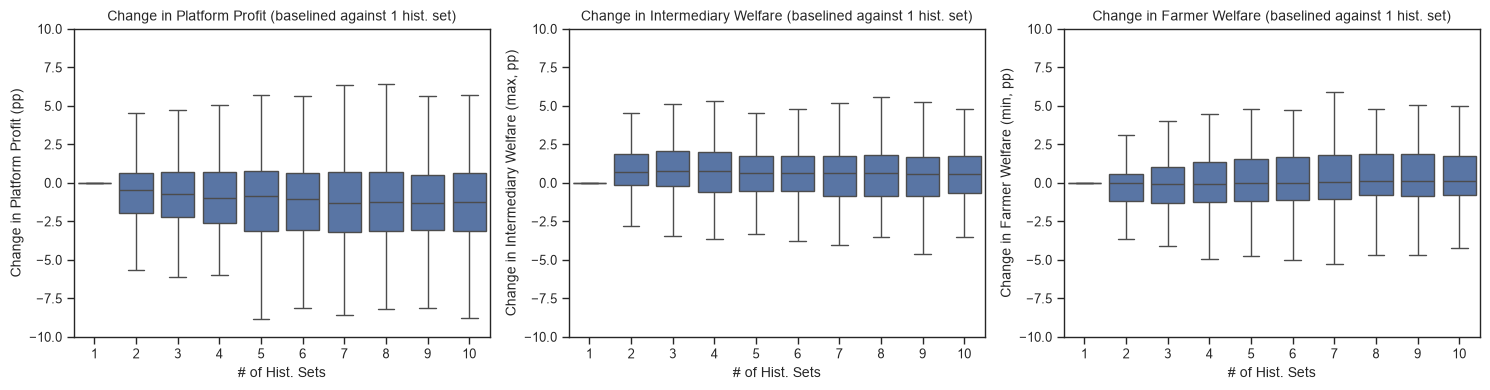

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(
    df_original,
    x="n_hist_sets",
    y="platform_profit_pct_baselined",
    showfliers=False,
    ax=axes[0]
)
axes[0].set_title("Change in Platform Profit (baselined against 1 hist. set)")
axes[0].set_xlabel("# of Hist. Sets")
axes[0].set_ylabel("Change in Platform Profit (pp)")
axes[0].set_ylim(-10, 10)

sns.boxplot(
    df_original,
    x="n_hist_sets",
    y="max_intermediary_welfare_pct_baselined",
    showfliers=False,
    ax=axes[1]
)
axes[1].set_title("Change in Intermediary Welfare (baselined against 1 hist. set)")
axes[1].set_xlabel("# of Hist. Sets")
axes[1].set_ylabel("Change in Intermediary Welfare (max, pp)")
axes[1].set_ylim(-10, 10)

sns.boxplot(
    df_original,
    x="n_hist_sets",
    y="min_farmer_welfare_pct_baselined",
    showfliers=False,
    ax=axes[2]
)
axes[2].set_title("Change in Farmer Welfare (baselined against 1 hist. set)")
axes[2].set_xlabel("# of Hist. Sets")
axes[2].set_ylabel("Change in Farmer Welfare (min, pp)")
axes[2].set_ylim(-10, 10)

plt.tight_layout()
plt.savefig("../figures/exp_3/welfare_change_boxplots.png", bbox_inches='tight', dpi=300)
plt.show()

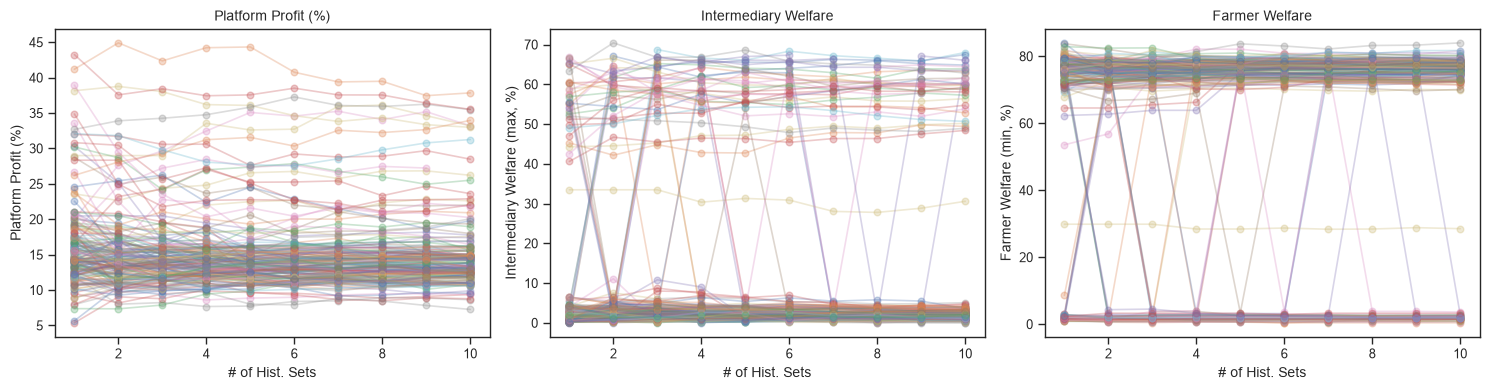

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for job_id, group in df_original.groupby("job_id"):
    group = group.sort_values("n_hist_sets")
    axes[0].plot(group["n_hist_sets"], group["platform_profit_pct"], alpha=0.3, marker="o")
    axes[0].set_xlabel("# of Hist. Sets")
    axes[0].set_ylabel("Platform Profit (%)")
    axes[0].set_title("Platform Profit (%)")
    axes[1].plot(group["n_hist_sets"], group["max_intermediary_welfare_pct"], alpha=0.3, marker="o")
    axes[1].set_xlabel("# of Hist. Sets")
    axes[1].set_ylabel("Intermediary Welfare (max, %)")
    axes[1].set_title("Intermediary Welfare")
    axes[2].plot(group["n_hist_sets"], group["min_farmer_welfare_pct"], alpha=0.3, marker="o")
    axes[2].set_xlabel("# of Hist. Sets")
    axes[2].set_ylabel("Farmer Welfare (min, %)")
    axes[2].set_title("Farmer Welfare")

plt.tight_layout()
plt.savefig("../figures/exp_3/welfare_lineplots.png", bbox_inches='tight', dpi=300)
plt.show()


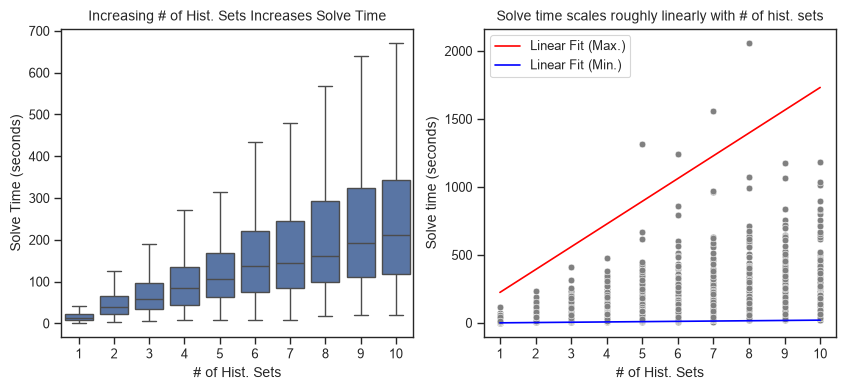

In [9]:
from numpy.polynomial import Polynomial

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(
    data=df_original,
    x="n_hist_sets",
    y="total_time",
    showfliers=False,
    ax=axes[0]
)

axes[0].set_xlabel("# of Hist. Sets")
axes[0].set_ylabel("Solve Time (seconds)")
axes[0].set_title("Increasing # of Hist. Sets Increases Solve Time")

df_max = df_original.groupby("n_hist_sets")["total_time"].max().reset_index()
p_fit_max = Polynomial.fit(df_max['n_hist_sets'], df_max['total_time'], deg=1)
df_min = df_original.groupby("n_hist_sets")["total_time"].min().reset_index()
p_fit_min = Polynomial.fit(df_min['n_hist_sets'], df_min['total_time'], deg=1)
df_mean = df_original.groupby("n_hist_sets")["total_time"].mean().reset_index()
p_fit_mean = Polynomial.fit(df_mean['n_hist_sets'], df_mean['total_time'], deg=1)

x_curve = np.linspace(df_original['n_hist_sets'].min(), df['n_hist_sets'].max())
y_max_curve = p_fit_max(x_curve)
y_min_curve = p_fit_min(x_curve)  # Evaluates the NumPy polynomial at those points


sns.scatterplot(df_original, x="n_hist_sets", y="total_time", color='gray', ax=axes[1])
axes[1].plot(x_curve, y_max_curve, color='red', label='Linear Fit (Max.)')
axes[1].plot(x_curve, y_min_curve, color='blue', label='Linear Fit (Min.)')

axes[1].set_xlabel("# of Hist. Sets")
axes[1].set_xticks(range(1, 11))
axes[1].set_ylabel("Solve time (seconds)")
axes[1].set_title("Solve time scales roughly linearly with # of hist. sets")
axes[1].legend()

plt.savefig("../figures/exp_3/n_hist_sets_scaling.png", bbox_inches='tight', dpi=300)
plt.show()